<a href="https://colab.research.google.com/github/dileepmon2/Power-System-Fault-Classification-Shallow/blob/main/Copy_of_MLGRIDFAULT_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Dataset Loaded: (5732, 362)
                                 nameList  labelList  csvOutput_1  \
0  CAP_CAPBREAKER_init_Closed_T0.2000.mat          4     1.001291   
1  CAP_CAPBREAKER_init_Closed_T0.2005.mat          4     1.001291   
2  CAP_CAPBREAKER_init_Closed_T0.2010.mat          4     1.001291   
3  CAP_CAPBREAKER_init_Closed_T0.2015.mat          4     1.001291   
4  CAP_CAPBREAKER_init_Closed_T0.2020.mat          4     1.001291   

   csvOutput_2  csvOutput_3   csvOutput_4  csvOutput_5  csvOutput_6  \
0     9.523618     1.500984 -2.420034e-14     2.038152     0.006158   
1     9.523618     1.500984 -2.420034e-14     2.038152     0.006158   
2     9.523618     1.500984 -2.420034e-14     2.038152     0.006158   
3     9.523618     1.500984 -2.420034e-14     2.038152     0.006158   
4     9.523618     1.500984 -2.420034e-14     2.038152     0.006158   

   csvOutput_7  csvOutput_8  ...  csvOutput_351  csvOutput_352  csvOutput_353  \
0     7.870671     5.72

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        92,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,023 (523.53 KB)

 Trainable params: 134,023 (523.53 KB)

 Non-trainable params: 0 (0.00 B)


Class Weights: {0: np.float64(4.094285714285714), 1: np.float64(0.2584776334776335), 2: np.float64(0.9477513227513228), 3: np.float64(1.3647619047619048), 4: np.float64(4.094285714285714), 5: np.float64(2.047142857142857), 6: np.float64(2.7295238095238097)}
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4759 - loss: 1.3961 - val_accuracy: 0.9357 - val_loss: 0.1978
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9009 - loss: 0.2566 - val_accuracy: 0.9269 - val_loss: 0.1588
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9560 - loss: 0.1394 - val_accuracy: 0.9640 - val_loss: 0.0745
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9693 - loss: 0.0963 - val_accuracy: 0.9586 - val_loss: 0.0972
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9691 - loss: 0.0861 - val_accuracy: 0.9836 - val_loss: 0.0382
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9723 - loss: 0.0948 - val_accuracy

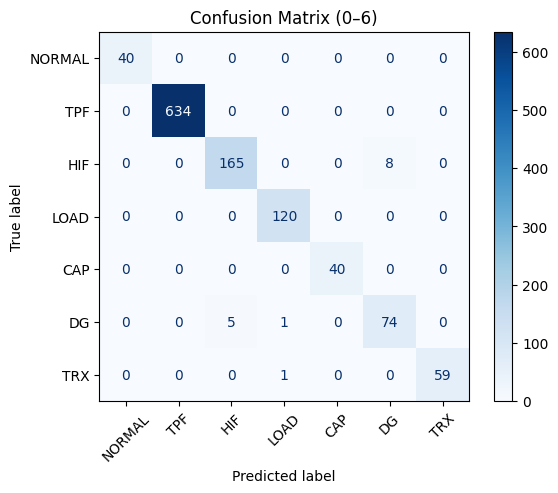


Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        40
         TPF       1.00      1.00      1.00       634
         HIF       0.97      0.95      0.96       173
        LOAD       0.98      1.00      0.99       120
         CAP       1.00      1.00      1.00        40
          DG       0.90      0.93      0.91        80
         TRX       1.00      0.98      0.99        60

    accuracy                           0.99      1147
   macro avg       0.98      0.98      0.98      1147
weighted avg       0.99      0.99      0.99      1147



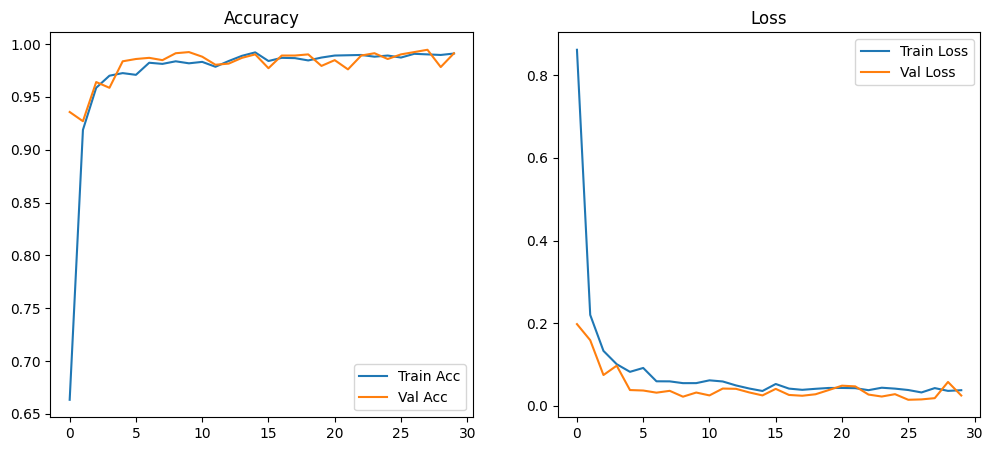

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# ==========================
# 1. LOAD DATA
# ==========================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML_GRID_PROJECT/ExtractedDataset_Labeled.csv")

print("Dataset Loaded:", df.shape)
print(df.head())

df = df.fillna(0)

# ==========================
# 2. FEATURE / LABEL SPLIT
# ==========================
X = df.drop(columns=["nameList", "labelList"]).values
y = df["labelList"].values  # labels 0–6

num_classes = len(np.unique(y))
print("Detected Classes:", np.unique(y))

# One-hot encode 0–6 → 7 classes
y_cat = to_categorical(y, num_classes=num_classes)

# ==========================
# 3. TRAIN–TEST SPLIT
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

print("\nTRAIN SET CLASS DISTRIBUTION:")
train_labels = np.argmax(y_train, axis=1)
for c, v in zip(*np.unique(train_labels, return_counts=True)):
    print(f"Class {c}: {v} samples")

print("\nTEST SET CLASS DISTRIBUTION:")
test_labels = np.argmax(y_test, axis=1)
for c, v in zip(*np.unique(test_labels, return_counts=True)):
    print(f"Class {c}: {v} samples")

# ==========================
# 4. NORMALIZATION
# ==========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# 5. BUILD MODEL
# ==========================
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ==========================
# 6. CLASS WEIGHTS
# ==========================
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weights = {i: cw[i] for i in range(len(cw))}
print("\nClass Weights:", class_weights)

# ==========================
# 7. TRAIN MODEL
# ==========================
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# ==========================
# 8. EVALUATE
# ==========================
loss, acc = model.evaluate(X_test, y_test)
print("\nTEST ACCURACY:", acc)

# ==========================
# 9. CONFUSION MATRIX
# ==========================
y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)

fault_names = [
    "NORMAL",  # 0
    "TPF",     # 1
    "HIF",     # 2
    "LOAD",    # 3
    "CAP",     # 4
    "DG",      # 5
    "TRX"      # 6
]

cm = confusion_matrix(y_true_class, y_pred_class)

disp = ConfusionMatrixDisplay(cm, display_labels=fault_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (0–6)")
plt.show()

# ==========================
# 10. CLASSIFICATION REPORT
# ==========================
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(
    y_true_class,
    y_pred_class,
    target_names=fault_names
))

# ==========================
# 11. ACCURACY & LOSS PLOTS
# ==========================
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.show()
